# Experiment 4: Logistic Regression
## Objective
Apply logistic regression for binary classification using the **Student Performance dataset from Experiment 2**.

**Task:** Predict `pass_fail` (0 = Fail, 1 = Pass) from information available before the final examination.

**Requirements:** Python, pandas, NumPy, Matplotlib, scikit-learn, and the original `student_performance.csv`. Keep the CSV beside this notebook or upload it to Google Colab. The earlier notebook references the CSV but does not embed its records. No real-data results are prefilled here.

### Learning outcomes
Prepare data without leakage; train a binary classifier; distinguish probabilities from labels; evaluate against a baseline; interpret a confusion matrix, classification report, ROC curve and coefficients.

### Connection to Experiment 3
Linear regression predicts a continuous score. Logistic regression estimates the probability of a class. Here, the target changes from `final_exam_score` to `pass_fail`.

## 1. Theory
The model combines the input features into a score:
\[
z=b_0+b_1x_1+\cdots+b_kx_k,\qquad P(y=1\mid X)=\frac{1}{1+e^{-z}}.
\]
The sigmoid maps the score to a probability between 0 and 1. We explicitly classify a student as Pass when the estimated probability is at least 0.50.

Despite its name, logistic regression is used for classification. Multiple input features still produce **binary** classification because the target has only two classes. Scikit-learn's default model uses regularization to discourage excessively large coefficients.

## 2. Import libraries
If imports fail in a new environment, run `%pip install pandas numpy matplotlib scikit-learn` in a separate cell, then restart the kernel.

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 3. Load the same CSV
Edit `DATA_PATH` if your file is stored elsewhere. Do not use the scaled arrays from Experiment 2: create a fresh split for this target and fit preprocessing only on training rows.

In [5]:
DATA_PATH = Path("/kaggle/input/datasets/tahreemrashid/student-performance-dataset/student_performance.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Place the original student_performance.csv beside this notebook "
        "or change DATA_PATH to its location."
    )
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())
df.info()

Dataset shape: (1000, 15)


,student_id,name,gender,age,class,teacher_id,subject,test1_score,test2_score,final_exam_score,final_grade_letter,attendance_percentage,study_hours_per_week,assignments_submitted,pass_fail
0,1,Carson Rivera,Female,14,9th,105,Math,23.5,40.5,50.5,F,70.2,3.1,56.7,0
1,2,Ashley Walters,Male,15,10th,107,Computer,77.7,80.6,82.3,B,85.3,6.9,81.0,1
2,3,Linda Robinson,Male,15,10th,103,English,75.0,73.4,64.5,C,83.1,4.3,66.3,1
3,4,Brandon James,Female,17,11th,117,Computer,46.7,53.1,51.2,F,74.1,0.4,44.9,0
4,5,Helen Grant,Female,16,10th,112,Science,38.0,57.3,47.6,F,73.8,1.4,49.9,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             1000 non-null   int64  
 1   name                   1000 non-null   object 
 2   gender                 1000 non-null   object 
 3   age                    1000 non-null   int64  
 4   class                  1000 non-null   object 
 5   teacher_id             1000 non-null   int64  
 6   subject                1000 non-null   object 
 7   test1_score            1000 non-null   float64
 8   test2_score            1000 non-null   float64
 9   final_exam_score       1000 non-null   float64
 10  final_grade_letter     1000 non-null   object 
 11  attendance_percentage  1000 non-null   float64
 12  study_hours_per_week   1000 non-null   float64
 13  assignments_submitted  1000 non-null   float64
 14  pass_fail              1000 non-null   int64  
dtypes: fl

## 4. Choose inputs and target
Use five numerical, pre-final-exam inputs:
- `test1_score`, `test2_score`
- `attendance_percentage`
- `study_hours_per_week`
- `assignments_submitted`

Exclude `final_exam_score` and `final_grade_letter`: they may determine or reveal the outcome. Names and IDs are not predictors. This teaching model omits categorical columns to keep preprocessing transparent.

**Timing matters:** the chosen measurements must be available at prediction time. If attendance or assignments are recorded only after the outcome, use their earlier snapshots instead.

In [6]:
FEATURES = [
    "test1_score", "test2_score", "attendance_percentage",
    "study_hours_per_week", "assignments_submitted"
]
TARGET = "pass_fail"
missing_columns = sorted(set(FEATURES + [TARGET]) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Remove exact repeated records, not students who share feature values.
data = df.drop_duplicates().copy()
print("Exact duplicate rows removed:", len(df) - len(data))

# The previous dataset defines the target as numeric 0/1.
numeric_target = pd.to_numeric(data[TARGET], errors="coerce")
invalid_target = data[TARGET].notna() & (
    numeric_target.isna() | ~numeric_target.isin([0, 1])
)
if invalid_target.any():
    raise ValueError("pass_fail must contain 0 = Fail, 1 = Pass, or missing values.")
print("Rows with missing target removed:", numeric_target.isna().sum())
data[TARGET] = numeric_target
data = data.dropna(subset=[TARGET]).copy()
data[TARGET] = data[TARGET].astype(int)

# Unparseable or infinite predictor values become missing for imputation.
data[FEATURES] = data[FEATURES].apply(pd.to_numeric, errors="coerce")
data[FEATURES] = data[FEATURES].replace([np.inf, -np.inf], np.nan)
display(data[FEATURES].isna().sum().to_frame("Missing inputs"))
if data[TARGET].nunique() != 2:
    raise ValueError("Both Pass and Fail examples are required.")
display(data[FEATURES].describe().round(2))

Exact duplicate rows removed: 0
Rows with missing target removed: 0


,Missing inputs
test1_score,0
test2_score,0
attendance_percentage,0
study_hours_per_week,0
assignments_submitted,0


,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,63.94,66.13,82.14,4.26,68.98
std,14.76,14.95,6.90,2.29,14.09
min,17.10,24.40,63.90,0.00,22.80
25%,53.80,56.38,77.20,2.60,59.28
50%,64.00,65.70,82.10,4.10,68.50
75%,73.90,76.93,86.80,5.82,79.10
max,100.00,100.00,100.00,12.00,100.00


## 5. Inspect class balance
Accuracy can be misleading when one class is much more frequent. The positive class in this notebook is **Pass (1)**. Recall for Fail is shown separately in the classification report.

,Class,Count,Percentage
0,Fail,170,17.0
1,Pass,830,83.0


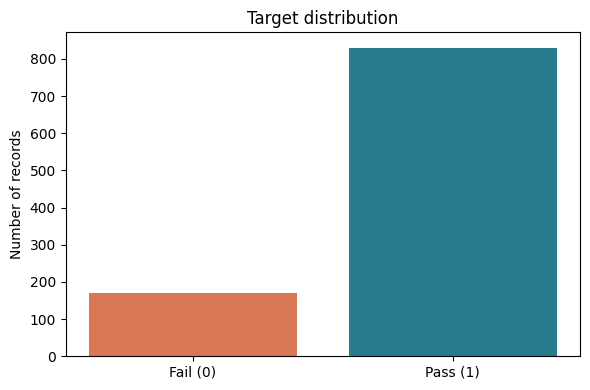

In [7]:
counts = data[TARGET].value_counts().reindex([0, 1], fill_value=0)
display(pd.DataFrame({
    "Class": ["Fail", "Pass"], "Count": counts.to_numpy(),
    "Percentage": (100 * counts / counts.sum()).to_numpy()
}).round(2))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Fail (0)", "Pass (1)"], counts.to_numpy(), color=["#d97757", "#287c8e"])
ax.set(title="Target distribution", ylabel="Number of records")
plt.tight_layout()
plt.show()

## 6. Split before fitting preprocessing
Normally use an 80:20 **stratified** split to preserve class proportions. If students have repeated records, keep each student's records in only one partition with a grouped split. This prevents the same student appearing in both training and testing. The grouped split is approximately 80:20 by groups and is not stratified.

Do not impute missing target labels. Do not compute imputation medians or scaling statistics from test data.

In [8]:
X = data[FEATURES]
y = data[TARGET]
if "student_id" in data.columns and data["student_id"].duplicated().any():
    if data["student_id"].isna().any():
        raise ValueError("Resolve missing student IDs before splitting repeated records.")
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(X, y, groups=data["student_id"]))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    assert set(data.loc[X_train.index, "student_id"]).isdisjoint(
        set(data.loc[X_test.index, "student_id"])
    )
    print("Used a student-grouped split.")
else:
    if y.value_counts().min() < 2:
        raise ValueError("Need at least two records of each class for stratification.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )
    print("Used a stratified random split.")

if y_train.nunique() != 2 or y_test.nunique() != 2:
    raise ValueError("This split lacks a class. Collect more data or design a valid split.")
if X_train.isna().all().any():
    raise ValueError("At least one predictor is entirely missing in training data.")
print("Training shape:", X_train.shape, "| Test shape:", X_test.shape)
display(pd.DataFrame({
    "Training": y_train.value_counts(), "Test": y_test.value_counts()
}).rename(index={0: "Fail", 1: "Pass"}))

Used a stratified random split.
Training shape: (800, 5) | Test shape: (200, 5)


,Training,Test
pass_fail,,
Pass,664,166
Fail,136,34


## 7. Build and train a leakage-safe pipeline
1. Fill missing input values with **training medians**.
2. Standardize using the **training mean and standard deviation**.
3. Fit logistic regression.

Scaling helps optimization and makes regularization more balanced across features. The pipeline applies the same learned transformations to testing and future records.

In [9]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])
model.fit(X_train, y_train)
print("Model trained.")
display(pd.DataFrame({
    "Feature": FEATURES,
    "Training median": model.named_steps["imputer"].statistics_
}))

Model trained.


,Feature,Training median
0,test1_score,65.15
1,test2_score,66.80
2,attendance_percentage,82.65
3,study_hours_per_week,4.20
4,assignments_submitted,69.35


## 8. Generate probabilities and class labels
`predict_proba` provides probabilities for both classes. We explicitly locate the column corresponding to Pass = 1.

In [10]:
pass_column = list(model.classes_).index(1)
pass_probability = model.predict_proba(X_test)[:, pass_column]
THRESHOLD = 0.50
y_pred = (pass_probability >= THRESHOLD).astype(int)
predictions = X_test.copy()
predictions["Actual"] = y_test
predictions["P(Pass)"] = pass_probability
predictions["Predicted"] = y_pred
predictions["Correct"] = y_test.to_numpy() == y_pred
display(predictions.head(15).round(3))

,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted,Actual,P(Pass),Predicted,Correct
438,62.3,56.1,64.5,3.1,35.3,0,0.069,0,True
875,43.6,42.5,71.7,0.0,52.4,0,0.069,0,True
154,62.0,73.1,90.6,5.0,66.3,1,0.997,1,True
664,57.4,59.0,80.1,3.9,66.9,1,0.971,1,True
984,45.1,44.4,77.2,2.7,68.6,0,0.703,1,False
476,70.4,86.0,93.8,5.5,88.1,1,1.000,1,True
406,60.3,62.2,78.7,1.5,53.3,1,0.851,1,True
912,52.4,69.5,75.4,2.7,52.2,1,0.718,1,True
12,56.8,61.4,79.4,3.3,58.5,1,0.896,1,True
854,56.0,47.9,83.8,1.9,67.4,1,0.941,1,True


## 9. Evaluate against a simple baseline
- **Accuracy:** fraction of all correct predictions.
- **Precision (Pass):** among predicted passes, fraction actually passing.
- **Recall (Pass):** among actual passes, fraction identified.
- **F1 (Pass):** harmonic mean of precision and recall.
- **ROC-AUC:** ranking performance across thresholds; 0.5 corresponds to random ranking.

The baseline always predicts the most frequent **training** class. Do not interpret a high accuracy alone as evidence of a useful classifier. Undefined precision/recall is reported as zero by the code.

In [11]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_probability = baseline.predict_proba(X_test)[:, list(baseline.classes_).index(1)]

def evaluate(name, labels, probabilities):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, labels),
        "Precision (Pass)": precision_score(y_test, labels, zero_division=0),
        "Recall (Pass)": recall_score(y_test, labels, zero_division=0),
        "F1 (Pass)": f1_score(y_test, labels, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    }

scores = pd.DataFrame([
    evaluate("Majority baseline", baseline_pred, baseline_probability),
    evaluate("Logistic regression", y_pred, pass_probability)
]).set_index("Model")
display(scores.round(4))
print(classification_report(
    y_test, y_pred, labels=[0, 1], target_names=["Fail", "Pass"], zero_division=0
))

,Accuracy,Precision (Pass),Recall (Pass),F1 (Pass),ROC-AUC
Model,,,,,
Majority baseline,0.83,0.8300,1.0000,0.9071,0.5000
Logistic regression,0.93,0.9524,0.9639,0.9581,0.9663


              precision    recall  f1-score   support

        Fail       0.81      0.76      0.79        34
        Pass       0.95      0.96      0.96       166

    accuracy                           0.93       200
   macro avg       0.88      0.86      0.87       200
weighted avg       0.93      0.93      0.93       200



## 10. Confusion matrix and ROC curve
With Pass as positive:
- TN: actual Fail, predicted Fail
- FP: actual Fail, predicted Pass
- FN: actual Pass, predicted Fail
- TP: actual Pass, predicted Pass

False positives can mean overlooking a student who needs support. Inspect **Fail recall**, not only Pass recall.

TN=26, FP=8, FN=6, TP=160


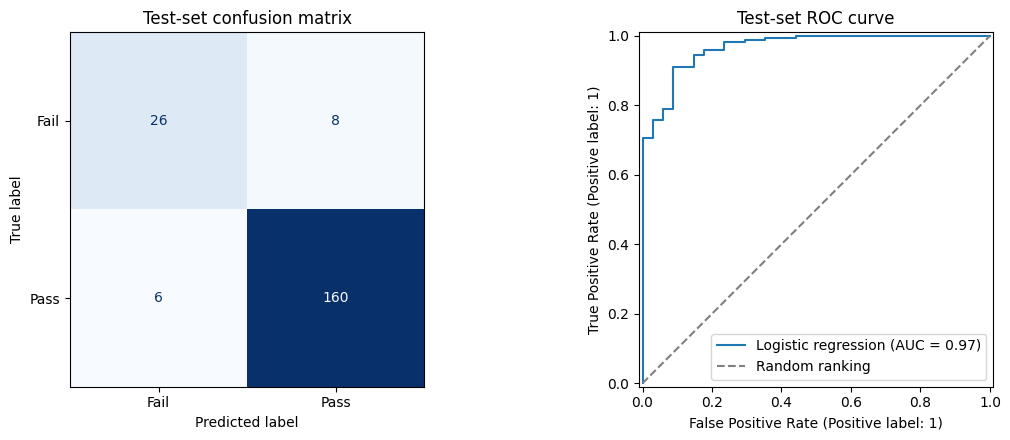

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["Fail", "Pass"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Test-set confusion matrix")
RocCurveDisplay.from_predictions(
    y_test, pass_probability, name="Logistic regression", ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Random ranking")
axes[1].set_title("Test-set ROC curve")
axes[1].legend()
plt.tight_layout()
plt.show()

## 11. Interpret coefficients
Inputs were standardized. A coefficient describes the change in **log-odds of passing** associated with a one-standard-deviation increase in that predictor, holding other predictors fixed. A positive coefficient increases estimated odds; a negative one decreases them. Exponentiating gives an odds ratio, **not a probability ratio**.

These associations are not causal. Correlated inputs, missing-value imputation and regularization affect coefficients.

In [13]:
coefficients = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": model.named_steps["classifier"].coef_[0]
})
coefficients["Odds ratio per standardized unit"] = np.exp(coefficients["Coefficient"])
display(coefficients.sort_values("Coefficient", ascending=False).round(4))
print("Intercept:", round(model.named_steps["classifier"].intercept_[0], 4))

,Feature,Coefficient,Odds ratio per standardized unit
4,assignments_submitted,2.4099,11.1332
0,test1_score,1.8676,6.4724
1,test2_score,1.2644,3.5409
2,attendance_percentage,0.4880,1.6290
3,study_hours_per_week,-0.0270,0.9733


Intercept: 5.6558


## 12. Predict for a new student
The following record is **hypothetical**, not an observation from the original CSV. Replace values using the same units as the dataset. Predictions are estimates for teaching, not automatic academic decisions.

In [14]:
new_student = pd.DataFrame([{
    "test1_score": 65,
    "test2_score": 70,
    "attendance_percentage": 85,
    "study_hours_per_week": 12,
    "assignments_submitted": 90
}])
new_probability = model.predict_proba(new_student)[:, pass_column][0]
print(f"Estimated probability of Pass: {new_probability:.1%}")
print("Predicted class:", "Pass" if new_probability >= THRESHOLD else "Fail")

Estimated probability of Pass: 100.0%
Predicted class: Pass


## 13. Optional: understand threshold changes
A higher Pass threshold generally predicts fewer passes, potentially finding more students at risk of failure, at the cost of more false failure alerts.

Choose a threshold using a **validation set or cross-validation**, based on the intended cost of errors. Do not choose it by optimizing final test scores. This demonstration uses only the hypothetical new student's probability.

In [15]:
display(pd.DataFrame({
    "Pass threshold": [0.30, 0.50, 0.70],
    "P(Pass)": [new_probability] * 3,
    "Prediction": [
        "Pass" if new_probability >= threshold else "Fail"
        for threshold in [0.30, 0.50, 0.70]
    ]
}))

,Pass threshold,P(Pass),Prediction
0,0.3,0.999928,Pass
1,0.5,0.999928,Pass
2,0.7,0.999928,Pass


## 14. Lab observations and conclusion
Run all cells on the original CSV, then record:
1. Number of training/test records and the class distribution.
2. Baseline and logistic-regression accuracy, F1 and ROC-AUC.
3. TN, FP, FN, TP and recall for Fail.
4. Whether the classifier improves on the majority baseline.
5. Two limitations and one possible improvement.

**Conclusion template:** “Logistic regression was applied to classify students as Pass or Fail using five pre-examination features. Its test accuracy was ___, F1 for Pass was ___, and ROC-AUC was ___. Compared with the baseline, ___. The confusion matrix showed ___ students at risk of failure were missed.”

### Viva questions with short answers
1. **Why logistic rather than linear regression?** The target is binary, and logistic regression estimates class probabilities.
2. **What does the sigmoid do?** Converts a real-valued score to a value between 0 and 1.
3. **Probability versus class?** A probability expresses model-estimated likelihood; a threshold converts it into a label.
4. **Why scale predictors?** To support stable optimization and balanced regularization.
5. **Why split before imputing?** To prevent test-set statistics influencing training.
6. **Why exclude the final score and grade?** They may reveal the outcome and may not exist at prediction time.
7. **Why can accuracy mislead?** A majority-class prediction can achieve high accuracy on imbalanced data.
8. **What does ROC-AUC measure?** How well scores rank positives above negatives across thresholds.
9. **Does a positive coefficient prove causation?** No; it describes a conditional association.
10. **Why group repeated student records?** To avoid evaluating on students already represented in training.

### Practice tasks
- Repeat with only study hours; preserve the same split and compare a pre-planned model on validation data.
- Study class weighting using `class_weight="balanced"` and validation data.
- Add `subject` through one-hot encoding in a `ColumnTransformer`.
- Investigate calibration before treating predicted probabilities as reliable risk estimates.